# DISEASE → POVERTY: Visualisation

Detailed visualisation of the DISEASE→POVERTY conceptual metaphor mapping
from the LCC corpus: kernel heatmaps, sparse network graphs, and permutation null distributions.

In [1]:
from pathlib import Path

from intrarepresentational_alignment.analysis import setup_domain_analysis
from intrarepresentational_alignment.viz import (
    plot_kernel_heatmaps,
    plot_null_distributions,
    plot_semantic_graphs,
    print_domain_summary,
)

In [2]:
SOURCE_CONCEPT    = "STRUGGLE"
TARGET_CONCEPT    = "POVERTY"
LCC_PATH          = Path("data/en_small.xml")

EDGE_FRACTION     = 0.15
MCS_EDGE_FRACTION = 0.20
N_PERMS           = 1000
GED_THRESHOLD     = 0.40
SEED              = 42

In [3]:
r = setup_domain_analysis(
    LCC_PATH, SOURCE_CONCEPT, TARGET_CONCEPT,
    n_perms=N_PERMS, ged_threshold=GED_THRESHOLD,
    mcs_edge_fraction=MCS_EDGE_FRACTION,
    edge_fraction=EDGE_FRACTION, seed=SEED,
)
print_domain_summary(r.domain_result, SOURCE_CONCEPT, TARGET_CONCEPT)

K_S_dense, K_T_dense = r.domain_result.K_source, r.domain_result.K_target
K_S_sparse, K_T_sparse = r.K_S_sparse, r.K_T_sparse
cka_res, ged_res, wl_res, mcs_res = r.domain_result.cka, r.domain_result.ged, r.domain_result.wl, r.domain_result.mcs
src_texts, tgt_texts = r.src_texts, r.tgt_texts

STRUGGLE -> POVERTY: 18 expression pairs
CKA = 0.262  (p = 0.916)
GED = 0.543  (p = 0.994)
WL  = 0.261  (p = 0.997)
MCS = 0.556  (p = 0.367)


## Kernel matrices: before and after pruning

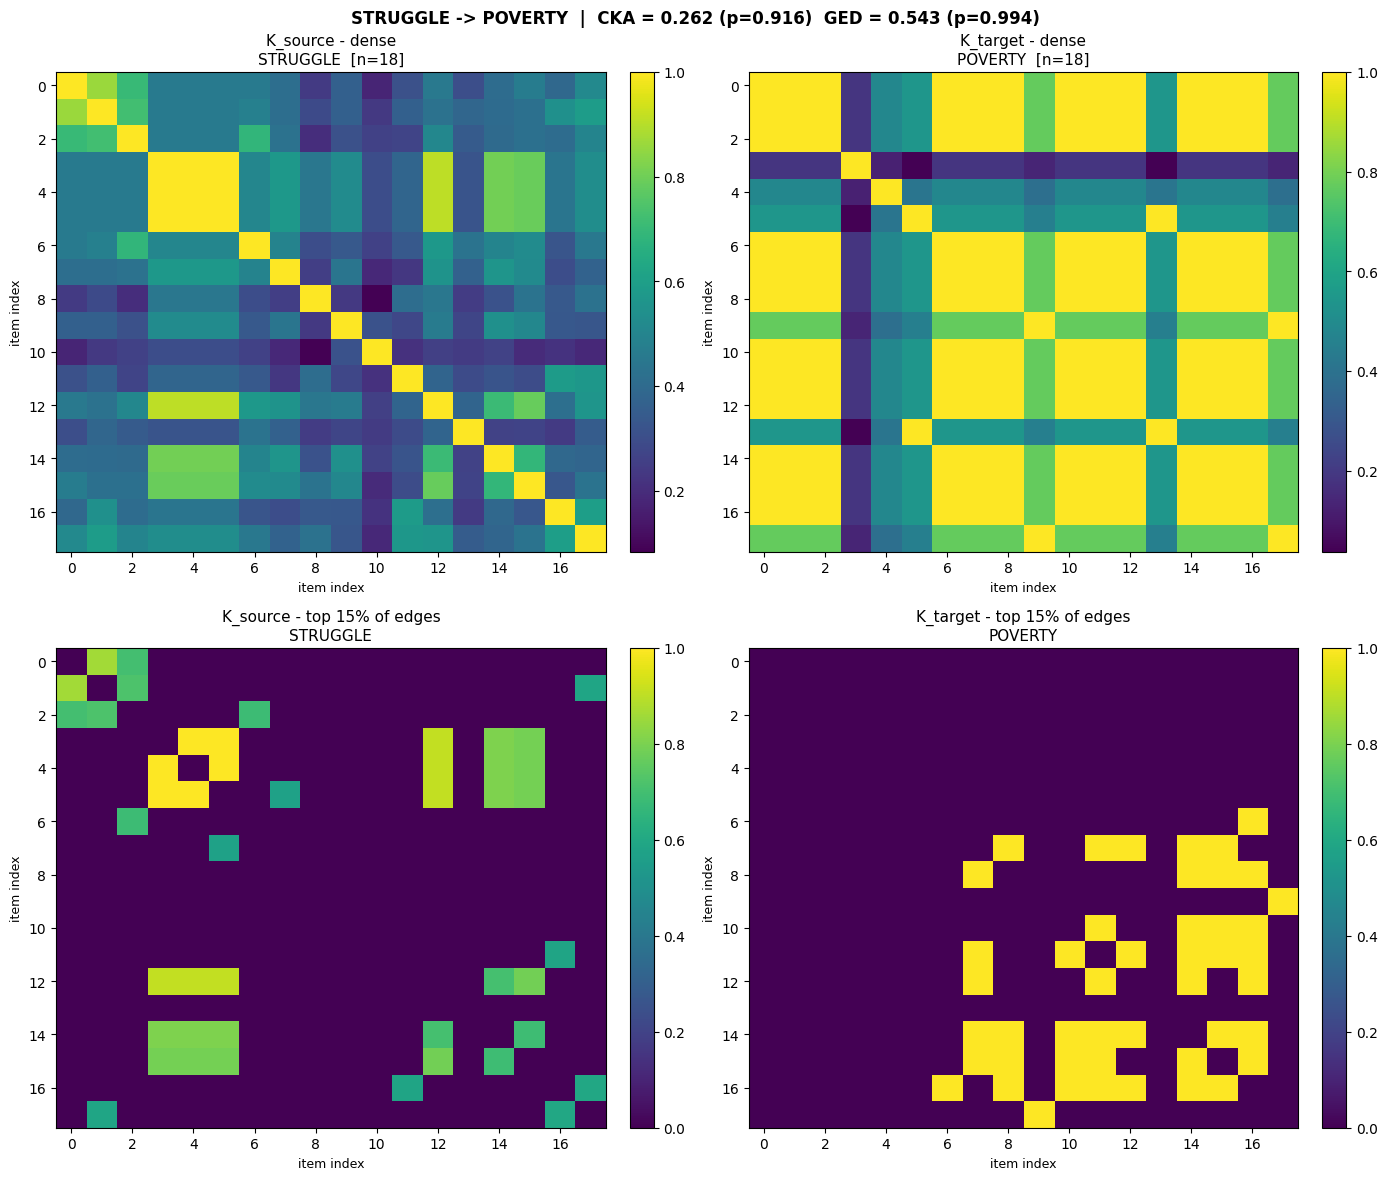

In [4]:
plot_kernel_heatmaps(K_S_dense, K_T_dense, K_S_sparse, K_T_sparse,
                     SOURCE_CONCEPT, TARGET_CONCEPT, EDGE_FRACTION, cka_res, ged_res)

## Network graphs (TopFraction sparsification)

Nodes are individual expressions; edges are retained by TopFraction and weighted by cosine similarity.

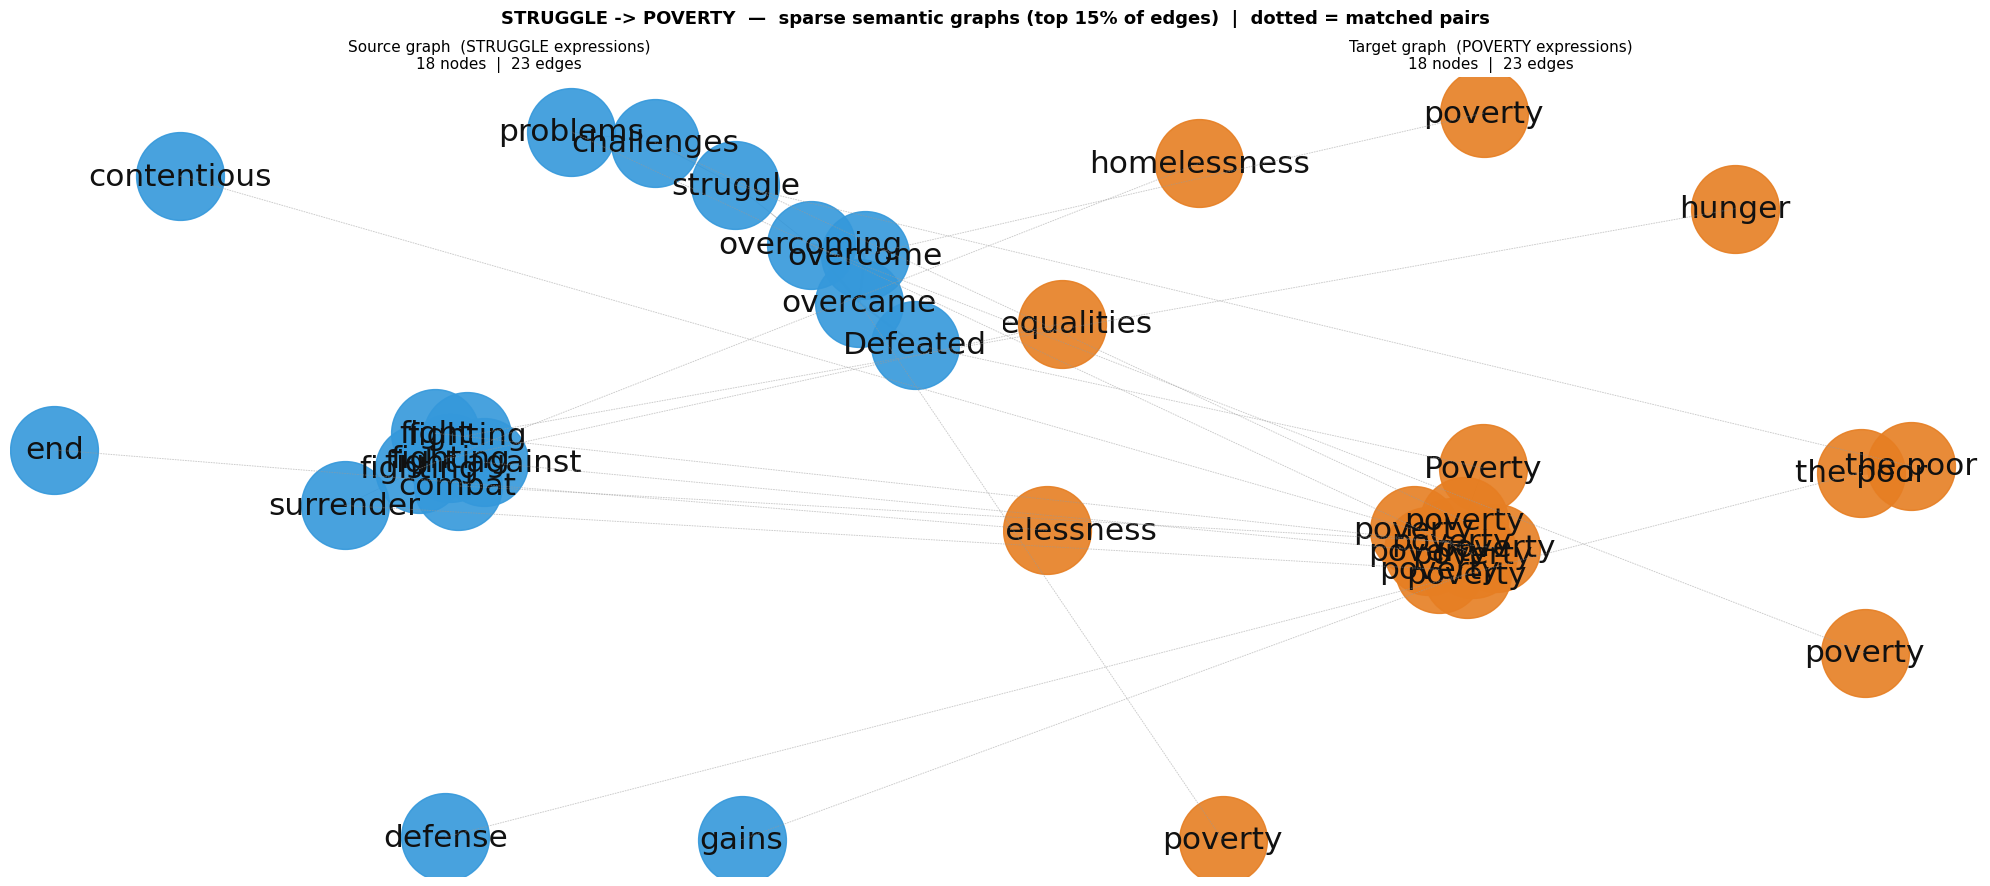

In [5]:
plot_semantic_graphs(K_S_sparse, K_T_sparse, src_texts, tgt_texts,
                     SOURCE_CONCEPT, TARGET_CONCEPT, EDGE_FRACTION)

## Permutation null distributions

Grey histograms = CKA/GED scores under the null (pairs shuffled). Red line = observed score.

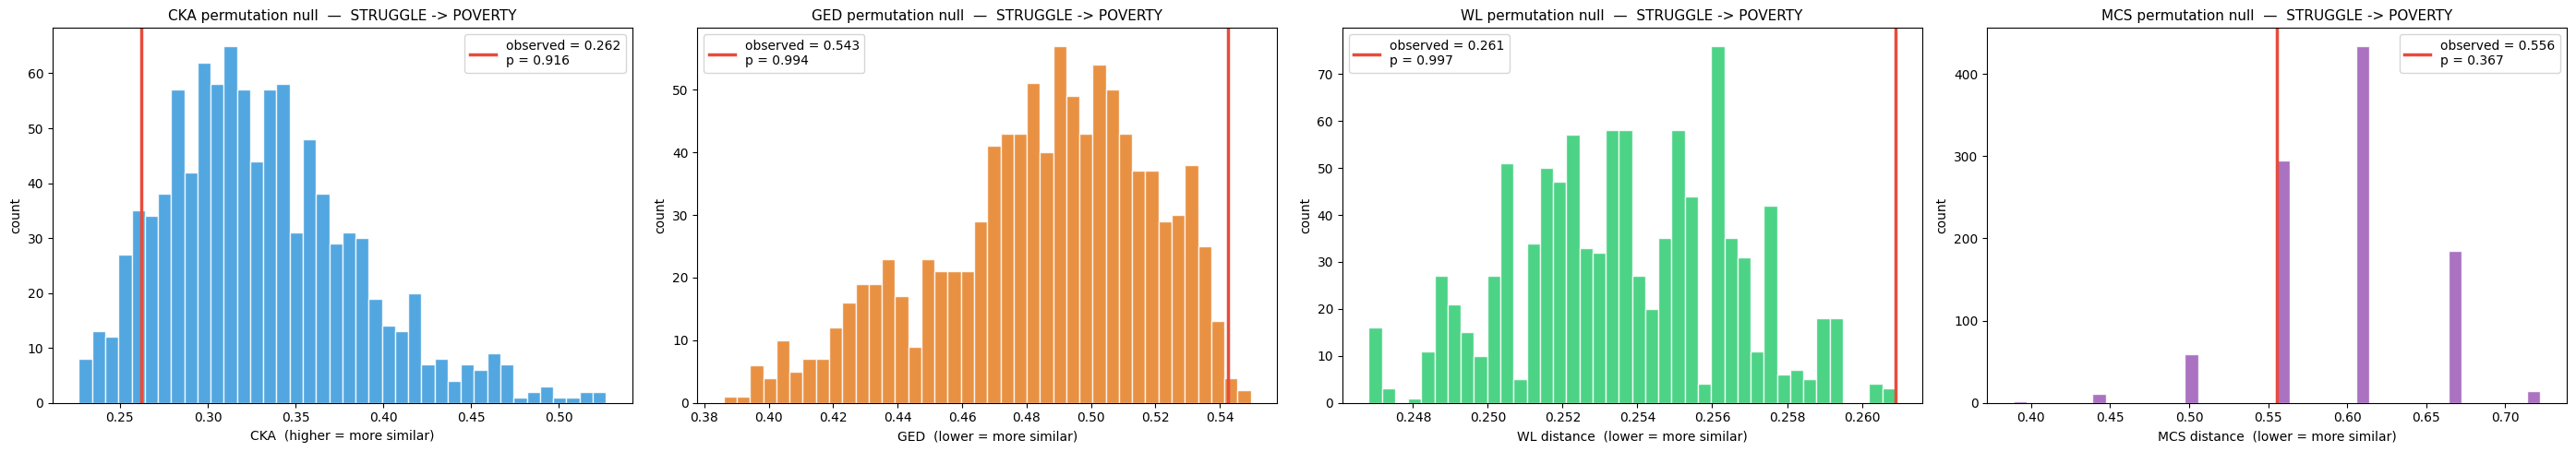

In [6]:
plot_null_distributions(cka_res, ged_res, SOURCE_CONCEPT, TARGET_CONCEPT, wl_res=wl_res, mcs_res=mcs_res)